# ☁️ Tahap 5: Visualisasi WordCloud

Notebook ini menghasilkan **WordCloud** untuk setiap model dan setiap kelas sentimen,
berdasarkan bobot fitur (koefisien model LR/SVM atau log-probabilitas NB).

**Prasyarat:** Notebook `03_modeling.ipynb` sudah dijalankan terlebih dahulu
(model sudah tersimpan di `output/`).

**Input (dari `output/`):**
- `model_names.json`
- `*.pkl` (model-model)
- `tfidf_vectorizer.pkl`
- `label_encoder.pkl`

**Output:** Gambar WordCloud per model → `output/<nama_model>_wordcloud.png`

In [1]:
# ── Setup Path ──────────────────────────────────────────────────────────────
import os
import sys

def _find_root(start):
    """Cari root directory project (berisi folder 'src' dan 'data')."""
    d = start
    for _ in range(5):
        if os.path.isdir(os.path.join(d, 'src')) and os.path.isdir(os.path.join(d, 'data')):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    return start

ROOT_DIR   = _find_root(os.path.abspath(os.getcwd()))
SRC_DIR    = os.path.join(ROOT_DIR, 'src')
OUTPUT_DIR = os.path.join(ROOT_DIR, 'output')

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f'ROOT_DIR   : {ROOT_DIR}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')

ROOT_DIR   : D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3
OUTPUT_DIR : D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output


In [2]:
# ── Import ──────────────────────────────────────────────────────────────────
import json
import pickle

from utils import plot_wordcloud_all_models

In [3]:
# ── Load Model Names ──────────────────────────────────────────────────────────
model_names_path = os.path.join(OUTPUT_DIR, 'model_names.json')
with open(model_names_path, 'r') as f:
    model_names = json.load(f)

print(f'Model yang ditemukan: {model_names}')

Model yang ditemukan: ['LR (Sebelum SMOTE)', 'SVM (Sebelum SMOTE)', 'NB (Sebelum SMOTE)', 'LR (Sesudah SMOTE)', 'SVM (Sesudah SMOTE)', 'NB (Sesudah SMOTE)']


In [4]:
# ── Load Semua Model ──────────────────────────────────────────────────────────
models = {}
for nama in model_names:
    nama_file = nama.replace(' ', '_').replace('(', '').replace(')', '') + '.pkl'
    path = os.path.join(OUTPUT_DIR, nama_file)
    with open(path, 'rb') as f:
        models[nama] = pickle.load(f)
    print(f'  Loaded: {nama_file}')

print(f'\nTotal model dimuat: {len(models)}')

  Loaded: LR_Sebelum_SMOTE.pkl
  Loaded: SVM_Sebelum_SMOTE.pkl
  Loaded: NB_Sebelum_SMOTE.pkl
  Loaded: LR_Sesudah_SMOTE.pkl
  Loaded: SVM_Sesudah_SMOTE.pkl
  Loaded: NB_Sesudah_SMOTE.pkl

Total model dimuat: 6


In [5]:
# ── Load TF-IDF Vectorizer & Label Encoder ───────────────────────────────────
with open(os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.pkl'), 'rb') as f:
    tfidf = pickle.load(f)

with open(os.path.join(OUTPUT_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)

print(f'Kelas label : {label_encoder.classes_}')
print(f'Jumlah fitur TF-IDF : {len(tfidf.get_feature_names_out()):,}')

Kelas label : ['Negatif' 'Netral' 'Positif']
Jumlah fitur TF-IDF : 10,000



[utils] Membuat WordCloud untuk: LR (Sebelum SMOTE)


[utils] WordCloud disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\LR_Sebelum_SMOTE_wordcloud.png


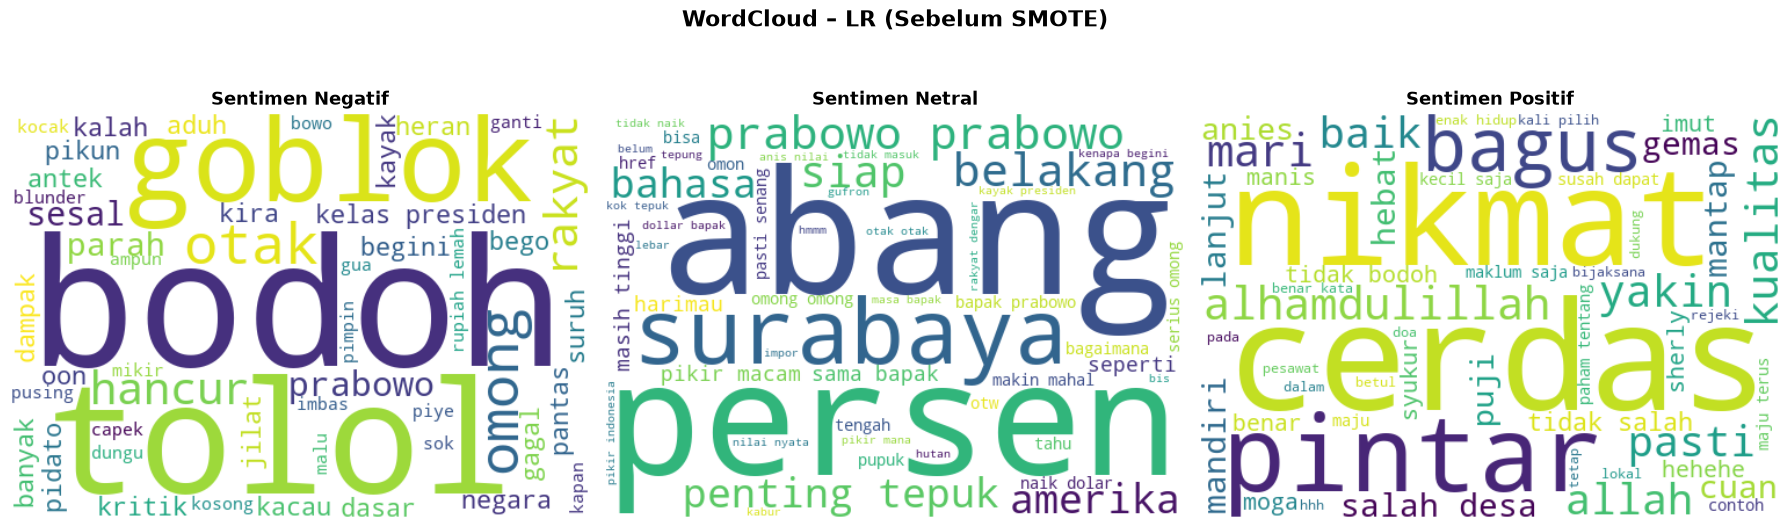


[utils] Membuat WordCloud untuk: SVM (Sebelum SMOTE)


[utils] WordCloud disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\SVM_Sebelum_SMOTE_wordcloud.png


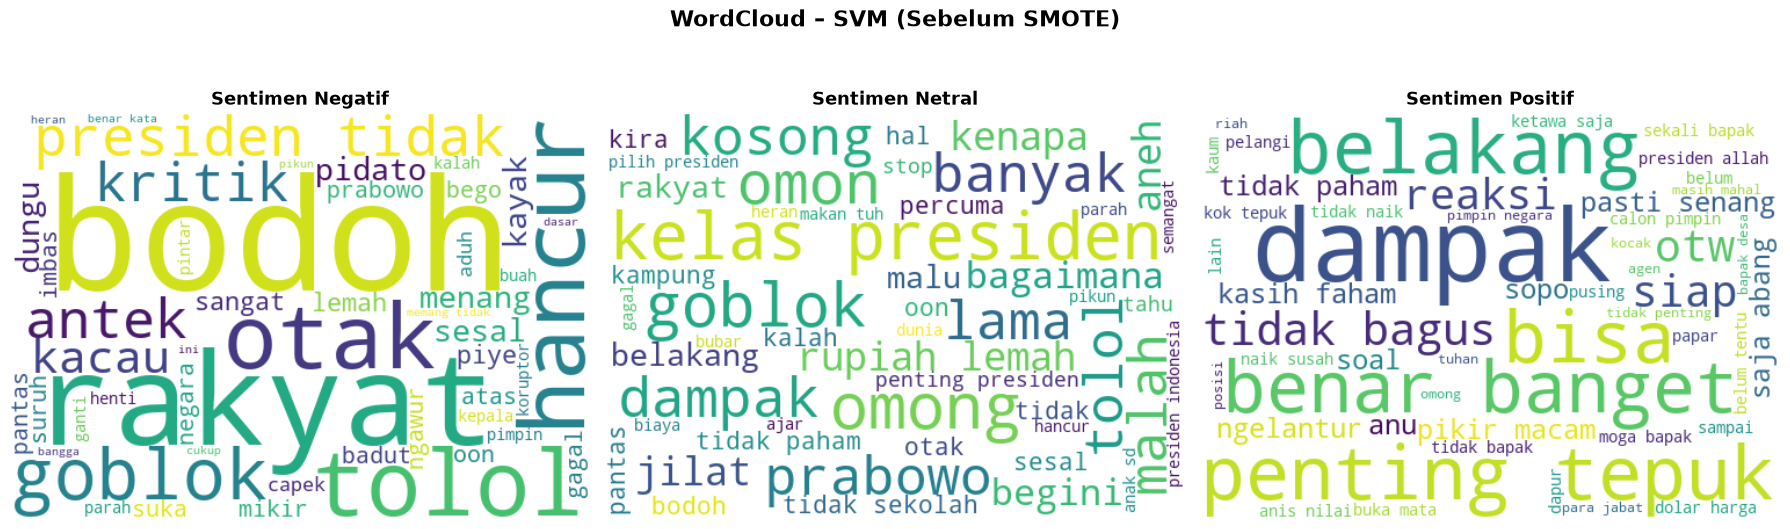


[utils] Membuat WordCloud untuk: NB (Sebelum SMOTE)


[utils] WordCloud disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\NB_Sebelum_SMOTE_wordcloud.png


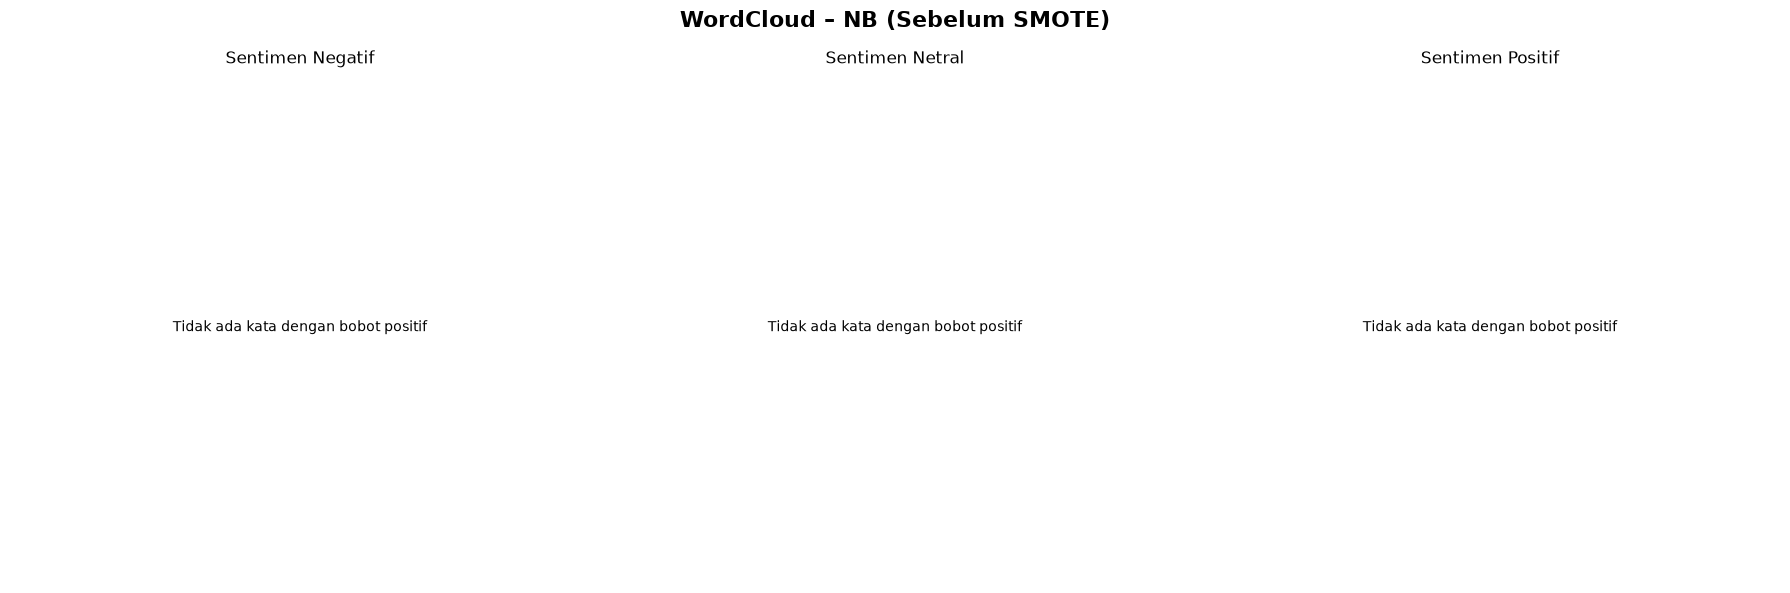


[utils] Membuat WordCloud untuk: LR (Sesudah SMOTE)


[utils] WordCloud disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\LR_Sesudah_SMOTE_wordcloud.png


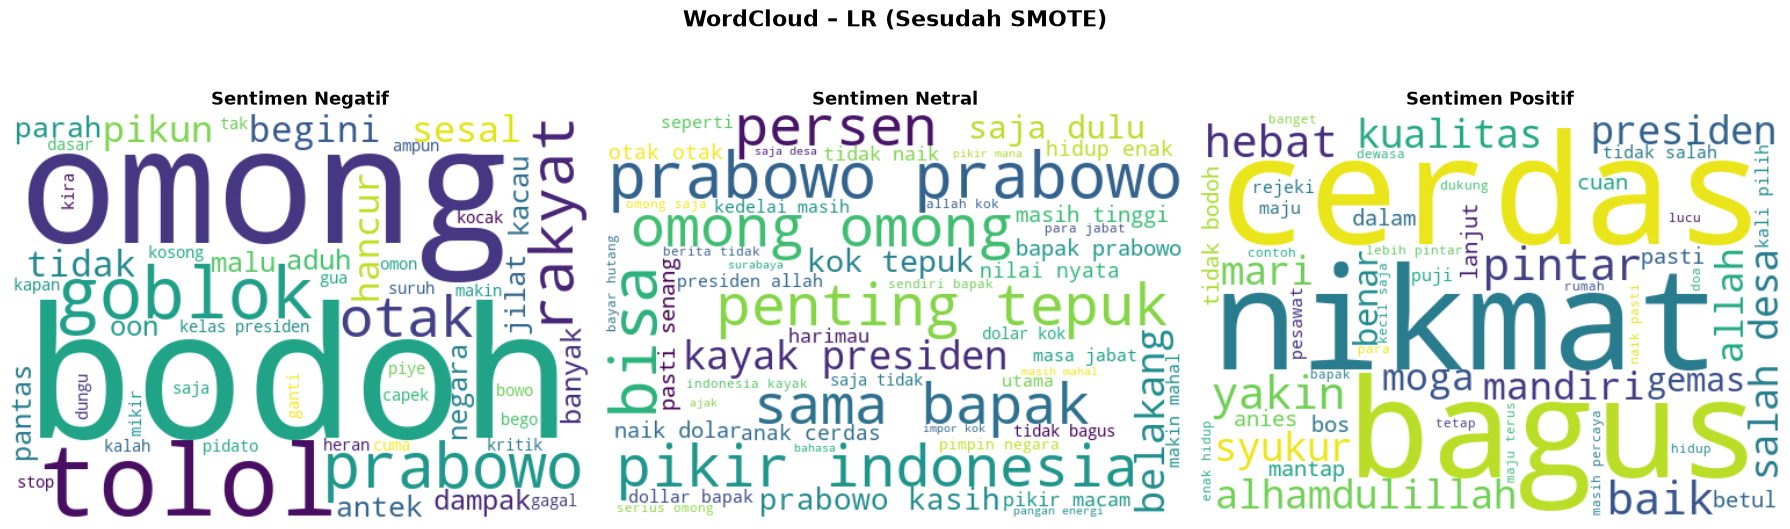


[utils] Membuat WordCloud untuk: SVM (Sesudah SMOTE)


[utils] WordCloud disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\SVM_Sesudah_SMOTE_wordcloud.png


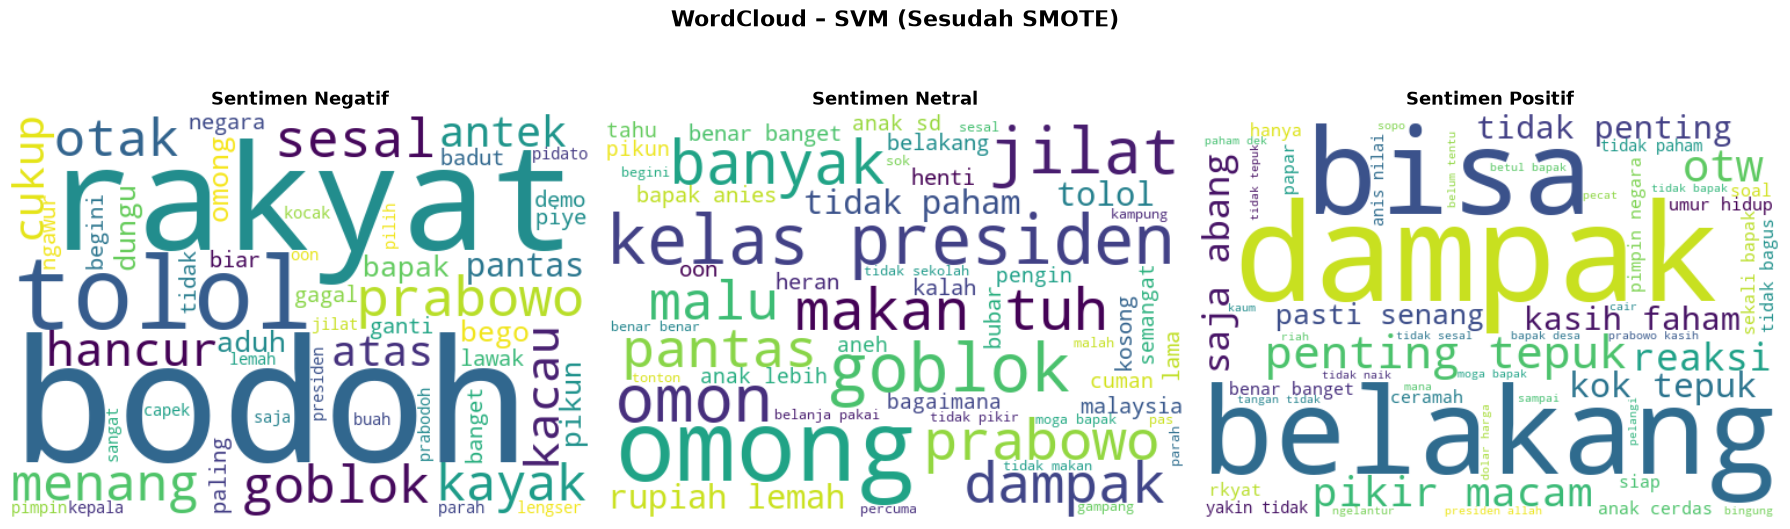


[utils] Membuat WordCloud untuk: NB (Sesudah SMOTE)


[utils] WordCloud disimpan: D:\Kuliah\Semester 6\Data Mining\Tubes\tugas-besar-datamining-kelompok3\output\NB_Sesudah_SMOTE_wordcloud.png


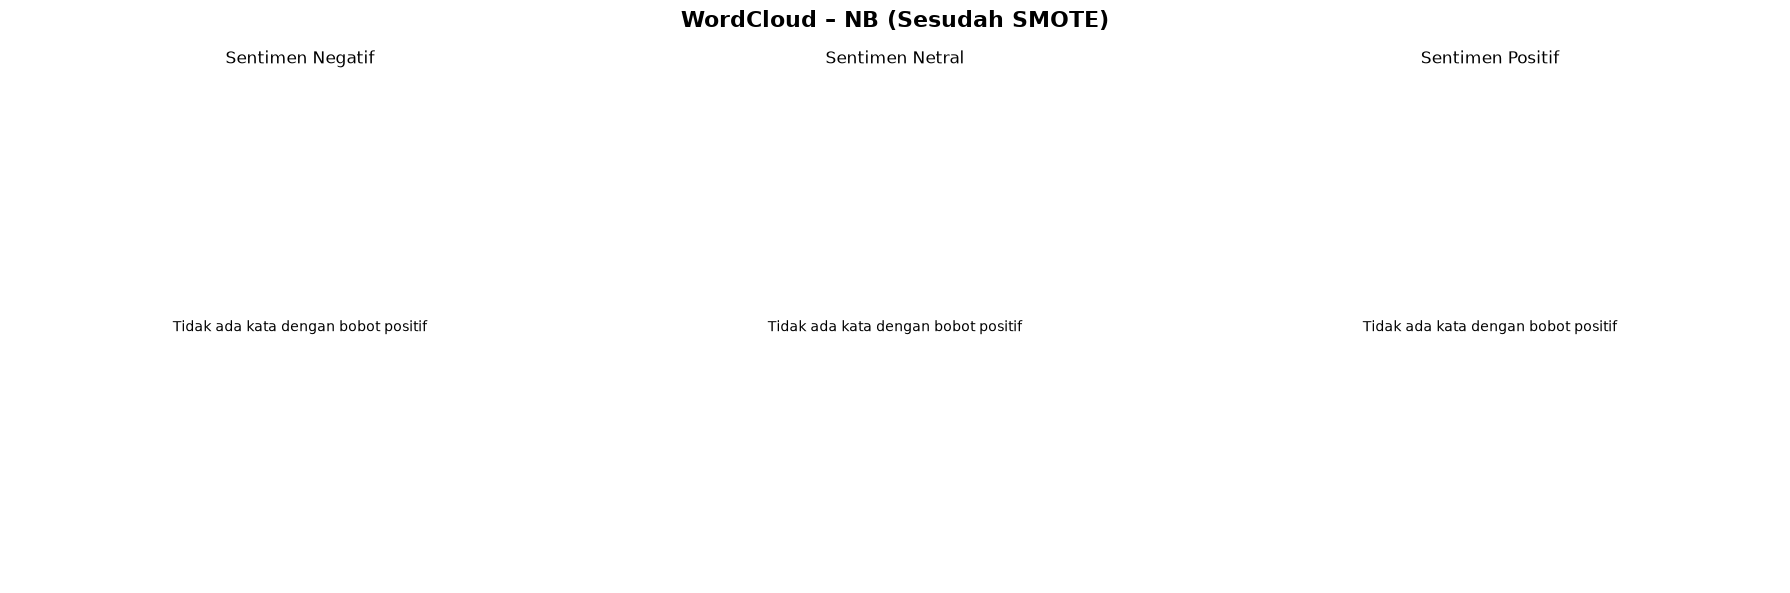

In [6]:
# ── Buat & Simpan WordCloud untuk Semua Model ─────────────────────────────────
plot_wordcloud_all_models(models, tfidf, label_encoder, save_dir=OUTPUT_DIR)